In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas_datareader.data as web
import datetime

from functions import get_polymarket_event, lead_lag_correlation, bootstrap_significance

In [2]:
march_event, march_probs = get_polymarket_event("fed-decision-in-march-885", "2026-03-18")
for name, df in march_probs.items():
    print(name, len(df), "points")

50+ bps decrease 240 points
25 bps decrease 240 points
No change 240 points
25+ bps increase 240 points


In [3]:
start_march = datetime.datetime(2026, 2, 18)
end_march = datetime.datetime(2026, 3, 17)

effr_march = web.DataReader('EFFR', 'fred', start_march, end_march)
r_before_march = effr_march['EFFR'].mean()
print(r_before_march)

3.6399999999999997


In [4]:
combined_march = pd.DataFrame()
for outcome_name, odf in march_probs.items():
    s = odf.set_index('datetime')['p'].resample('1min').last().ffill()
    combined_march[outcome_name] = s

combined_march = combined_march.dropna()
print(combined_march.head())
print(combined_march.tail())

                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
2026-03-18 12:00:00-04:00            0.0005           0.0015     0.9975   
2026-03-18 12:01:00-04:00            0.0005           0.0025     0.9975   
2026-03-18 12:02:00-04:00            0.0005           0.0025     0.9975   
2026-03-18 12:03:00-04:00            0.0005           0.0025     0.9975   
2026-03-18 12:04:00-04:00            0.0005           0.0025     0.9975   

                           25+ bps increase  
datetime                                     
2026-03-18 12:00:00-04:00            0.0005  
2026-03-18 12:01:00-04:00            0.0005  
2026-03-18 12:02:00-04:00            0.0005  
2026-03-18 12:03:00-04:00            0.0005  
2026-03-18 12:04:00-04:00            0.0005  
                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
20

In [5]:
prob_sum_march = (
    combined_march['50+ bps decrease'] +
    combined_march['25 bps decrease'] +
    combined_march['No change'] +
    combined_march['25+ bps increase']
)

combined_march['r_after'] = (
    (combined_march['50+ bps decrease'] / prob_sum_march) * (r_before_march - 0.50) +
    (combined_march['25 bps decrease'] / prob_sum_march) * (r_before_march - 0.25) +
    (combined_march['No change'] / prob_sum_march) * r_before_march +
    (combined_march['25+ bps increase'] / prob_sum_march) * (r_before_march + 0.25)
)

print(combined_march[['r_after']].head())
print(combined_march[['r_after']].tail())

                            r_after
datetime                           
2026-03-18 12:00:00-04:00  3.639500
2026-03-18 12:01:00-04:00  3.639251
2026-03-18 12:02:00-04:00  3.639251
2026-03-18 12:03:00-04:00  3.639251
2026-03-18 12:04:00-04:00  3.639251
                           r_after
datetime                          
2026-03-18 15:55:00-04:00  3.63975
2026-03-18 15:56:00-04:00  3.63975
2026-03-18 15:57:00-04:00  3.63975
2026-03-18 15:58:00-04:00  3.63975
2026-03-18 15:59:00-04:00  3.63975


In [6]:
zq_2026 = pd.read_csv('zq_2026.csv')
zq_2026['datetime'] = pd.to_datetime(zq_2026['time'], unit='s')
zq_2026['datetime'] = zq_2026['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')

march_zq_window = zq_2026[(zq_2026['datetime'] >= '2026-03-18 12:00:00') & (zq_2026['datetime'] <= '2026-03-18 16:00:00')].copy()
march_zq_window['implied_rate'] = 100 - march_zq_window['close']
print(march_zq_window.head())
print(march_zq_window.tail())

            time    open    high     low   close  Volume  \
2662  1773849600  96.360  96.360  96.360  96.360    1000   
2663  1773849660  96.355  96.355  96.355  96.355     347   
2664  1773849780  96.360  96.360  96.360  96.360      61   
2665  1773849840  96.360  96.360  96.360  96.360    1210   
2666  1773850440  96.360  96.360  96.360  96.360     600   

                      datetime  implied_rate  
2662 2026-03-18 12:00:00-04:00         3.640  
2663 2026-03-18 12:01:00-04:00         3.645  
2664 2026-03-18 12:03:00-04:00         3.640  
2665 2026-03-18 12:04:00-04:00         3.640  
2666 2026-03-18 12:14:00-04:00         3.640  
            time    open    high     low   close  Volume  \
2762  1773863700  96.355  96.355  96.355  96.355     738   
2763  1773863760  96.355  96.355  96.355  96.355    2870   
2764  1773863820  96.355  96.355  96.355  96.355    2025   
2765  1773863940  96.355  96.355  96.355  96.355     256   
2766  1773864000  96.355  96.355  96.355  96.355    1947 

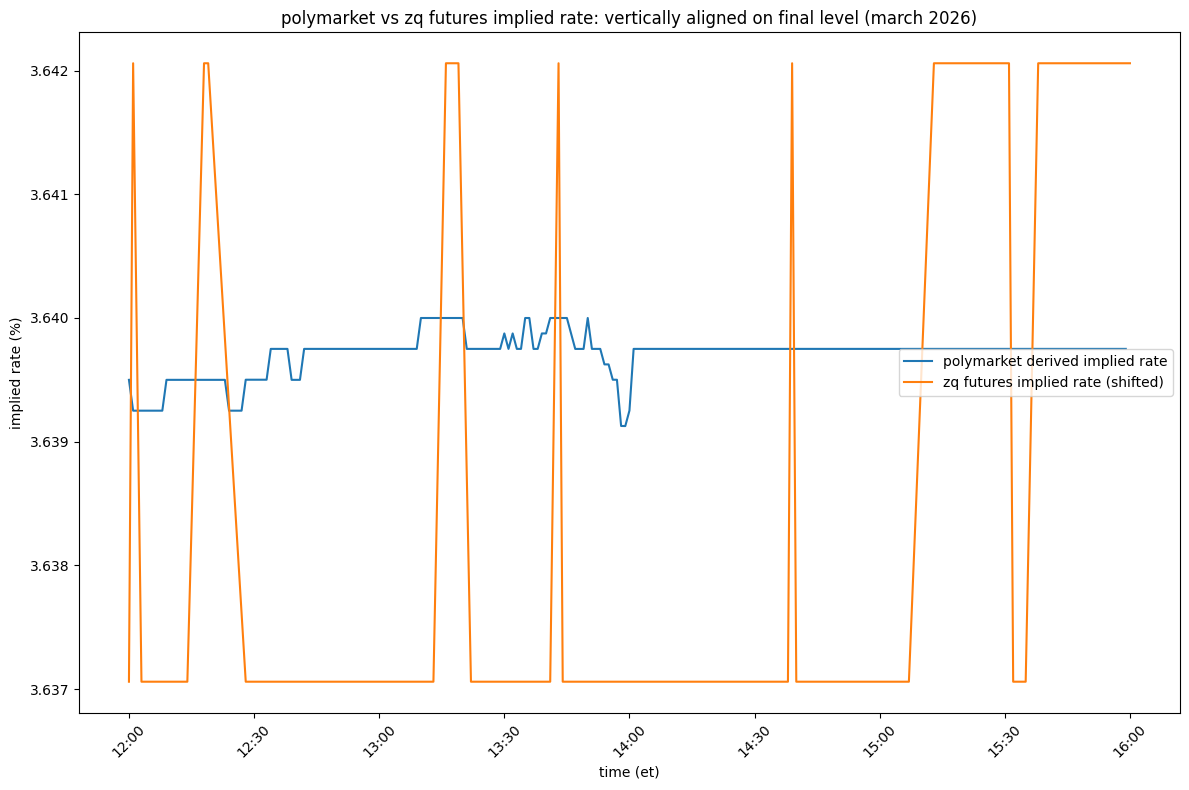

In [7]:
zq_final_march = march_zq_window[march_zq_window['datetime'] >= '2026-03-18 14:00:00']['implied_rate'].mean()
poly_final_march = combined_march[combined_march.index >= '2026-03-18 14:00:00']['r_after'].mean()
shift_march = poly_final_march - zq_final_march
march_zq_window['implied_rate_shifted'] = march_zq_window['implied_rate'] + shift_march

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_march.index, combined_march['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(march_zq_window['datetime'], march_zq_window['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: vertically aligned on final level (march 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=march_zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

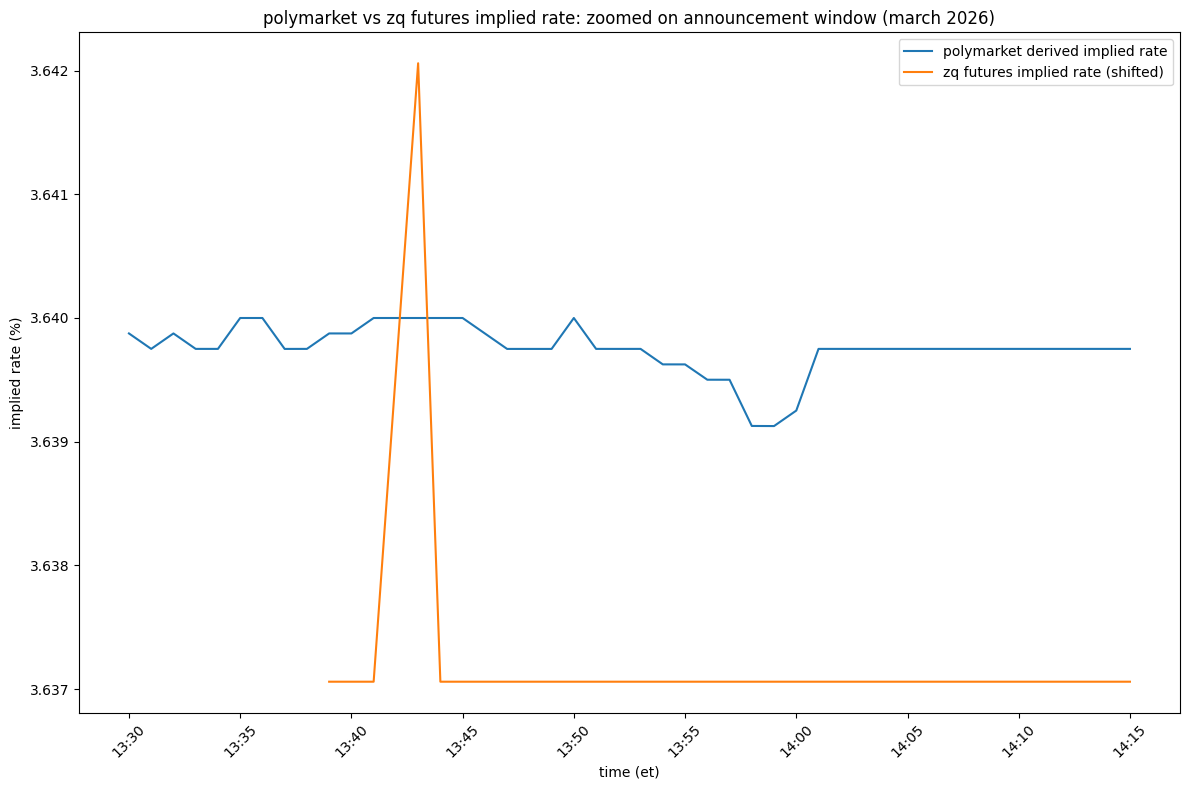

In [8]:
zoom_start_march = '2026-03-18 13:30:00'
zoom_end_march = '2026-03-18 14:15:00'

combined_zoom_march = combined_march[(combined_march.index >= zoom_start_march) & (combined_march.index <= zoom_end_march)]
zq_zoom_march = march_zq_window[(march_zq_window['datetime'] >= zoom_start_march) & (march_zq_window['datetime'] <= zoom_end_march)]

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_zoom_march.index, combined_zoom_march['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_zoom_march['datetime'], zq_zoom_march['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: zoomed on announcement window (march 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=march_zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
pre_window_march = combined_march[(combined_march.index >= '2026-03-18 13:40:00') & (combined_march.index <= '2026-03-18 13:58:00')]
poly_diff_pre_march = pre_window_march['r_after'].diff()

zq_pre_march = march_zq_window[(march_zq_window['datetime'] >= '2026-03-18 13:40:00') & (march_zq_window['datetime'] <= '2026-03-18 13:58:00')]
zq_diff_pre_march = zq_pre_march.set_index('datetime')['implied_rate'].diff()

print("polymarket real moves:")
print(poly_diff_pre_march[poly_diff_pre_march != 0].dropna())
print("\nzq real moves:")
print(zq_diff_pre_march[zq_diff_pre_march != 0].dropna())

polymarket real moves:
datetime
2026-03-18 13:41:00-04:00    1.249375e-04
2026-03-18 13:46:00-04:00   -1.249375e-04
2026-03-18 13:47:00-04:00   -1.250625e-04
2026-03-18 13:50:00-04:00    2.500000e-04
2026-03-18 13:51:00-04:00   -2.497502e-04
2026-03-18 13:52:00-04:00   -1.248127e-07
2026-03-18 13:53:00-04:00    1.248127e-07
2026-03-18 13:54:00-04:00   -1.252498e-04
2026-03-18 13:55:00-04:00   -1.875938e-07
2026-03-18 13:56:00-04:00   -1.238144e-04
2026-03-18 13:57:00-04:00   -2.491273e-07
2026-03-18 13:58:00-04:00   -3.735668e-04
Name: r_after, dtype: float64

zq real moves:
datetime
2026-03-18 13:43:00-04:00    0.005
2026-03-18 13:44:00-04:00   -0.005
Name: implied_rate, dtype: float64


In [10]:
print(march_zq_window[(march_zq_window['datetime'] >= '2026-03-18 14:00:00') & (march_zq_window['datetime'] <= '2026-03-18 14:15:00')][['datetime', 'implied_rate']])
print(combined_march[(combined_march.index >= '2026-03-18 14:00:00') & (combined_march.index <= '2026-03-18 14:15:00')][['r_after']])

                      datetime  implied_rate
2700 2026-03-18 14:00:00-04:00          3.64
2701 2026-03-18 14:01:00-04:00          3.64
2702 2026-03-18 14:02:00-04:00          3.64
2703 2026-03-18 14:08:00-04:00          3.64
2704 2026-03-18 14:09:00-04:00          3.64
2705 2026-03-18 14:10:00-04:00          3.64
2706 2026-03-18 14:11:00-04:00          3.64
2707 2026-03-18 14:12:00-04:00          3.64
2708 2026-03-18 14:15:00-04:00          3.64
                            r_after
datetime                           
2026-03-18 14:00:00-04:00  3.639251
2026-03-18 14:01:00-04:00  3.639750
2026-03-18 14:02:00-04:00  3.639750
2026-03-18 14:03:00-04:00  3.639750
2026-03-18 14:04:00-04:00  3.639750
2026-03-18 14:05:00-04:00  3.639750
2026-03-18 14:06:00-04:00  3.639750
2026-03-18 14:07:00-04:00  3.639750
2026-03-18 14:08:00-04:00  3.639750
2026-03-18 14:09:00-04:00  3.639750
2026-03-18 14:10:00-04:00  3.639750
2026-03-18 14:11:00-04:00  3.639750
2026-03-18 14:12:00-04:00  3.639750
2026-03-18

In [11]:
window_x = combined_march[(combined_march.index >= '2026-03-18 13:30:00') & (combined_march.index <= '2026-03-18 14:30:00')]['r_after']
window_y = march_zq_window.set_index('datetime')['implied_rate']
window_y = window_y[(window_y.index >= '2026-03-18 13:30:00') & (window_y.index <= '2026-03-18 14:30:00')]

lags_df, best_lag, best_corr = lead_lag_correlation(window_x, window_y, max_lag_minutes=30)
print(f"best lag: {best_lag}, best correlation: {best_corr:.3f}")
print(lags_df.sort_values('correlation', ascending=False).head())

best lag: 15, best correlation: 0.728
    lag  correlation  n_obs
17   15     0.728312     13
9     7     0.487294     21
13   11     0.417215     17
4     2     0.118044     26
1    -1     0.116491     27


In [12]:
lags_df, best_lag, best_corr = lead_lag_correlation(window_x, window_y, max_lag_minutes=30)
p_value = bootstrap_significance(window_x, window_y, observed_corr=best_corr, max_lag_minutes=30)
print(f"best lag: {best_lag}, best correlation: {best_corr:.3f}, p-value: {p_value:.3f}")

best lag: 15, best correlation: 0.728, p-value: 0.360
